<a href="https://colab.research.google.com/github/k2herat/DL_homeworks/blob/hw_6/hw_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def download_stock_data(ticker='AAPL', start_date='2020-01-01', end_date='2024-01-01'):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data

stock_data = download_stock_data('AAPL')

/tmp/ipython-input-898691368.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
class StockDataset(Dataset):
    def __init__(self, data, seq_length=60, pred_length=5, features=None):
        if features is None:
            features = ['Open', 'High', 'Low', 'Close', 'Volume']

        self.seq_length = seq_length
        self.pred_length = pred_length
        self.features = features

        self.scalers = {}
        self.normalized_data = pd.DataFrame()

        for feature in features:
            scaler = MinMaxScaler()
            self.normalized_data[feature] = scaler.fit_transform(data[feature].values.reshape(-1, 1)).flatten()
            self.scalers[feature] = scaler

        self.sequences = []
        self.targets = []

        for i in range(len(self.normalized_data) - seq_length - pred_length):
            seq = self.normalized_data.iloc[i:i+seq_length][features].values
            target = self.normalized_data.iloc[i+seq_length:i+seq_length+pred_length]['Close'].values

            self.sequences.append(seq)
            self.targets.append(target)

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx]), torch.FloatTensor(self.targets[idx])

    def inverse_transform(self, data, feature='Close'):
        return self.scalers[feature].inverse_transform(data.reshape(-1, 1)).flatten()

features = ['Open', 'High', 'Low', 'Close', 'Volume']
seq_length = 60
pred_length = 5

dataset = StockDataset(stock_data, seq_length=seq_length, pred_length=pred_length, features=features)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import math
from torch.autograd import Function
from einops import rearrange
import torch.nn.functional as F

class PScan(Function):
    @staticmethod
    def forward(ctx, A_inp, X_inp):
        A, X = A_inp.clone(), X_inp.clone()
        A, X = rearrange(A, "l b d s -> b d l s"), rearrange(X, "l b d s -> b d l s")
        PScan._forward(A, X)
        ctx.save_for_backward(A.clone(), X)
        return rearrange(X, "b d l s -> b l d s")

    @staticmethod
    def backward(ctx, grad_inp):
        A, X = ctx.saved_tensors
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_out = rearrange(grad_inp, "b l d s -> b d l s")
        grad_out = grad_out.flip(2)
        PScan._forward(A, grad_out)
        grad_out = grad_out.flip(2)
        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_out[:, :, 1:])
        return rearrange(Q, "b d l s -> b l d s"), rearrange(grad_out, "b d l s -> b l d s")

    @staticmethod
    def _forward(A, X):
        b, d, l, s = A.shape
        num_steps = int(math.log2(l))
        Av, Xv = A, X
        for _ in range(num_steps):
            T = Xv.size(2)
            Av, Xv = Av[:, :, :T].reshape(b, d, T//2, 2, -1), Xv[:, :, :T].reshape(b, d, T//2, 2, -1)
            Xv[:, :, :, 1].add_(Av[:, :, :, 1].mul(Xv[:, :, :, 0]))
            Av[:, :, :, 1].mul_(Av[:, :, :, 0])
            Av, Xv = Av[:, :, :, 1], Xv[:, :, :, 1]
        for k in range(num_steps-1, -1, -1):
            Av, Xv = A[:, :, 2**k-1:l:2**k], X[:, :, 2**k-1:l:2**k]
            T = 2 * (Xv.size(2) // 2)
            if T < Xv.size(2):
                Xv[:, :, -1].add_(Av[:, :, -1].mul(Xv[:, :, -2]))
                Av[:, :, -1].mul_(Av[:, :, -2])
            Av, Xv = Av[:, :, :T].reshape(b, d, T//2, 2, -1), Xv[:, :, :T].reshape(b, d, T//2, 2, -1)
            Xv[:, :, 1:, 0].add_(Av[:, :, 1:, 0].mul(Xv[:, :, :-1, 1]))
            Av[:, :, 1:, 0].mul_(Av[:, :, :-1, 1])

pscan = PScan.apply

class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        norm = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x * norm * self.weight


        return output + x_res


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MambaBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

        self.in_proj = nn.Linear(d_model, d_model * 2)
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)

        self.B_proj = nn.Linear(d_model, d_model)
        self.C_proj = nn.Linear(d_model, d_model)

        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch, seq_len, _ = x.shape

        x_proj = self.in_proj(x)
        x_res, x_ssm = x_proj.chunk(2, dim=-1)

        x_conv = self.conv1d(x_ssm.transpose(1, 2)).transpose(1, 2)
        x_conv = F.silu(x_conv)

        B = self.B_proj(x_conv)
        C = self.C_proj(x_conv)

        y = x_conv * B + C

        output = self.out_proj(y)
        return output + x_res

class Mamba(nn.Module):
    def __init__(self, num_layers, d_input, d_model):
        super().__init__()
        self.input_proj = nn.Linear(d_input, d_model)
        self.layers = nn.ModuleList([
            MambaBlock(d_model) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        x = x[:, -pred_length:, :]
        output = self.output_proj(x).squeeze(-1)
        return output

config = {
    'num_layers': 3,
    'd_input': len(features),
    'd_model': 64,
    'learning_rate': 0.001,
    'num_epochs': 20,
}

model = Mamba(
    num_layers=config['num_layers'],
    d_input=config['d_input'],
    d_model=config['d_model']
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(val_loader)

train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(config['num_epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mamba.pth')

    if epoch % 5 == 0:
        print(f'Epoch {epoch+1}/{config["num_epochs"]}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

print('Обучение завершено!')

Epoch 1/20, Train Loss: 0.103239, Val Loss: 0.011467
Epoch 6/20, Train Loss: 0.002029, Val Loss: 0.001573
Epoch 11/20, Train Loss: 0.001701, Val Loss: 0.001300
Epoch 16/20, Train Loss: 0.001747, Val Loss: 0.001286
Обучение завершено!


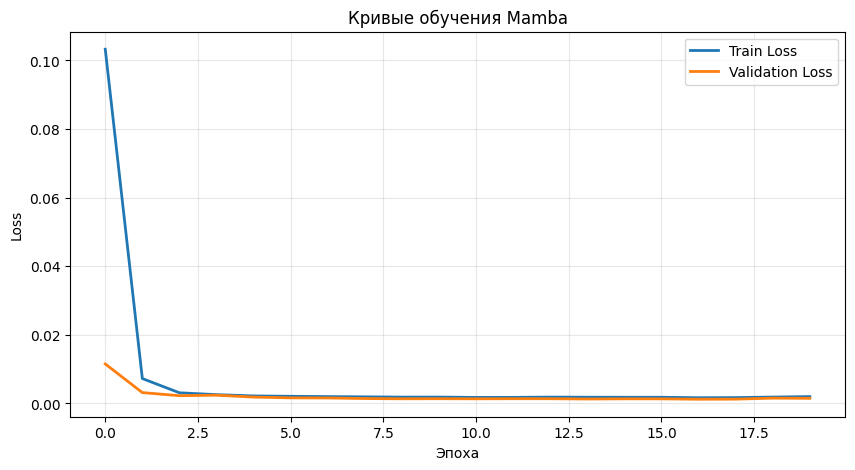

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.title('Кривые обучения Mamba')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model.load_state_dict(torch.load('best_mamba.pth'))
model.eval()

def test_model(model, test_loader, device):
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            output = model(data)
            predictions.append(output.cpu().numpy())
            targets.append(target.numpy())

    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)
    return predictions, targets

predictions, targets = test_model(model, test_loader, device)

print(f'Test predictions shape: {predictions.shape}')
print(f'Test targets shape: {targets.shape}')

Test predictions shape: (142, 5)
Test targets shape: (142, 5)


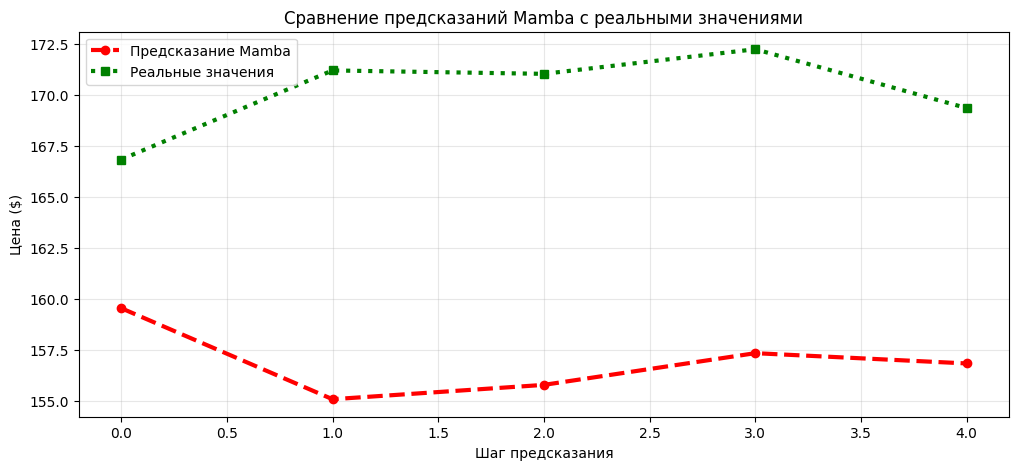

In [ ]:
sample_idx = 0
sample_data, sample_target = test_dataset[sample_idx]
sample_data = sample_data.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(sample_data).cpu().numpy()[0]

original_prediction = dataset.inverse_transform(prediction, 'Close')
original_target = dataset.inverse_transform(sample_target.numpy(), 'Close')

plt.figure(figsize=(12, 5))
plt.plot(range(len(original_prediction)), original_prediction, 'r--', label='Предсказание Mamba', linewidth=3, marker='o')
plt.plot(range(len(original_target)), original_target, 'g:', label='Реальные значения', linewidth=3, marker='s')
plt.title('Сравнение предсказаний Mamba с реальными значениями')
plt.xlabel('Шаг предсказания')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

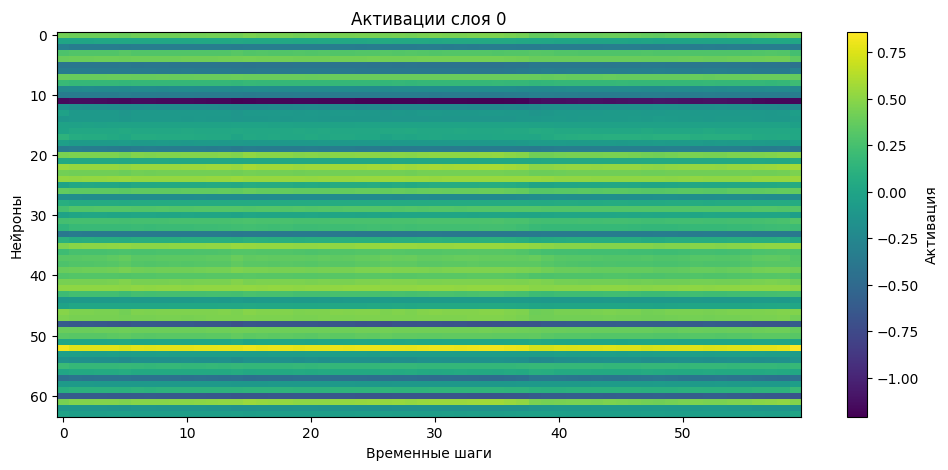

In [ ]:
def visualize_activations(model, sample_data, layer_idx=0):
    model.eval()
    sample_data = sample_data.to(device)

    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach().cpu().numpy())

    handle = model.layers[layer_idx].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(sample_data.unsqueeze(0))

    handle.remove()

    if activations:
        activation = activations[0][0]
        plt.figure(figsize=(12, 5))
        plt.imshow(activation.T, aspect='auto', cmap='viridis')
        plt.title(f'Активации слоя {layer_idx}')
        plt.xlabel('Временные шаги')
        plt.ylabel('Нейроны')
        plt.colorbar(label='Активация')
        plt.show()

sample_data, _ = train_dataset[0]
visualize_activations(model, sample_data, layer_idx=0)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(targets.flatten(), predictions.flatten())
mae = mean_absolute_error(targets.flatten(), predictions.flatten())

print(f'Final Test Metrics:')
print(f'MSE: {mse:.6f}')
print(f'MAE: {mae:.6f}')

errors = targets.flatten() - predictions.flatten()
print(f'Mean Error: {errors.mean():.6f}')
print(f'Std Error: {errors.std():.6f}')

Final Test Metrics:
MSE: 0.001642
MAE: 0.031623
Mean Error: 0.004766
Std Error: 0.040235


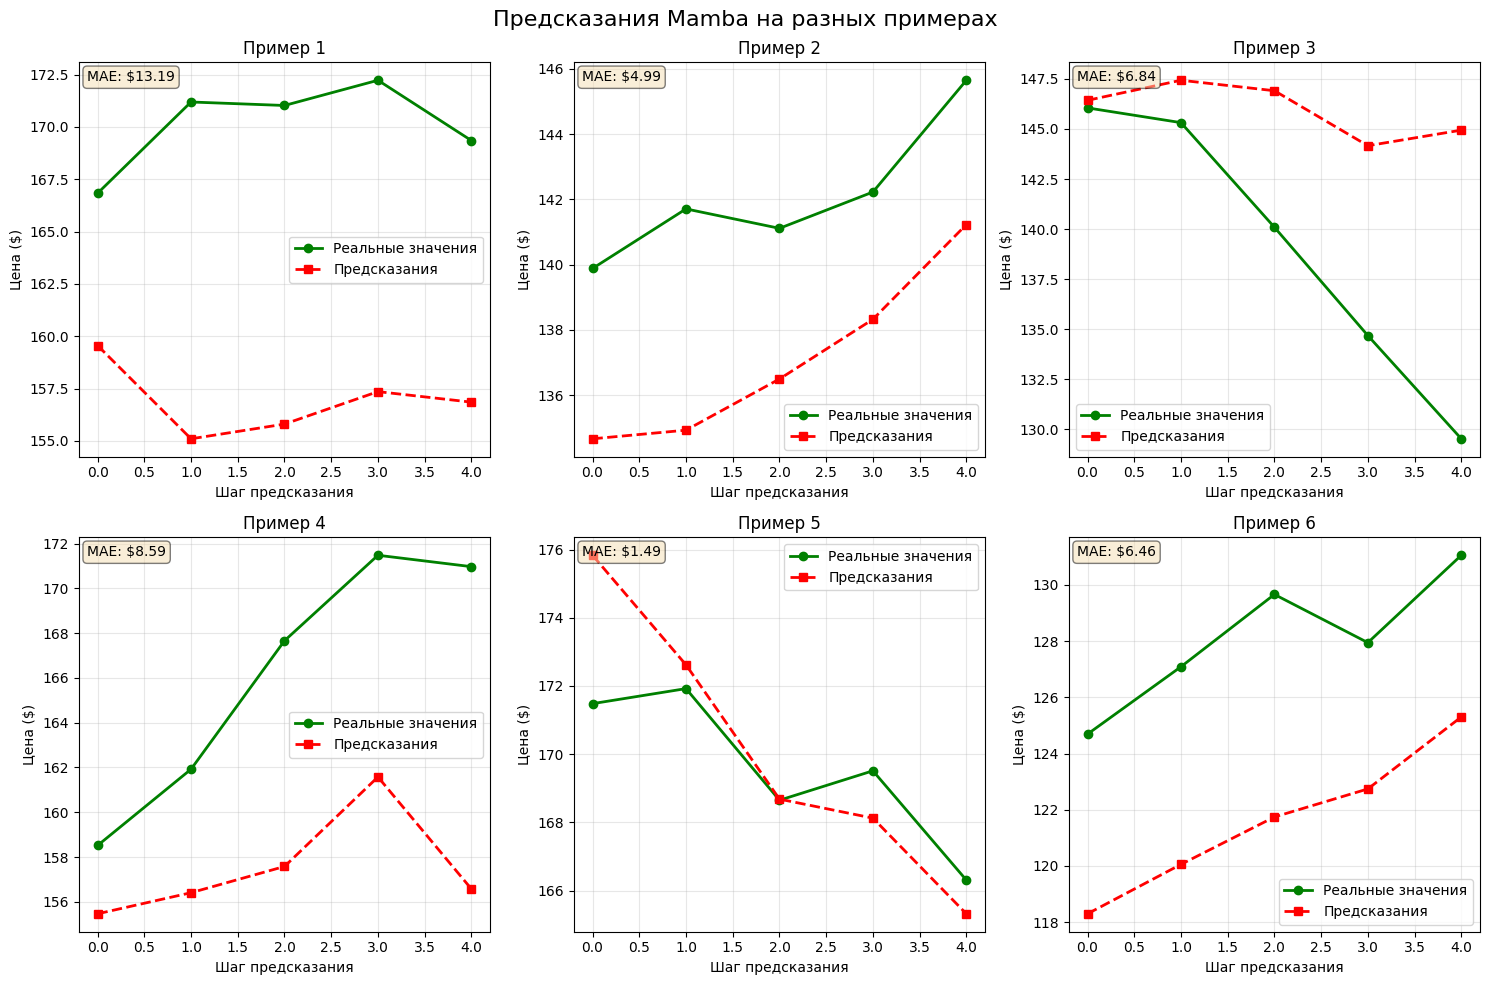

In [ ]:
model.load_state_dict(torch.load('best_mamba.pth'))
model.eval()

def plot_multiple_predictions(model, test_dataset, dataset, num_examples=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i in range(min(num_examples, len(test_dataset))):
        sample_data, sample_target = test_dataset[i]
        sample_data_tensor = sample_data.unsqueeze(0).to(device)

        with torch.no_grad():
            prediction = model(sample_data_tensor).cpu().numpy()[0]

        original_prediction = dataset.inverse_transform(prediction, 'Close')
        original_target = dataset.inverse_transform(sample_target.numpy(), 'Close')

        ax = axes[i]
        ax.plot(range(len(original_target)), original_target, 'g-', label='Реальные значения', linewidth=2, marker='o')
        ax.plot(range(len(original_prediction)), original_prediction, 'r--', label='Предсказания', linewidth=2, marker='s')
        ax.set_title(f'Пример {i+1}')
        ax.set_xlabel('Шаг предсказания')
        ax.set_ylabel('Цена ($)')
        ax.legend()
        ax.grid(True, alpha=0.3)

        errors = original_target - original_prediction
        ax.text(0.02, 0.98, f'MAE: ${np.abs(errors).mean():.2f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Предсказания Mamba на разных примерах', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_multiple_predictions(model, test_dataset, dataset, num_examples=6)

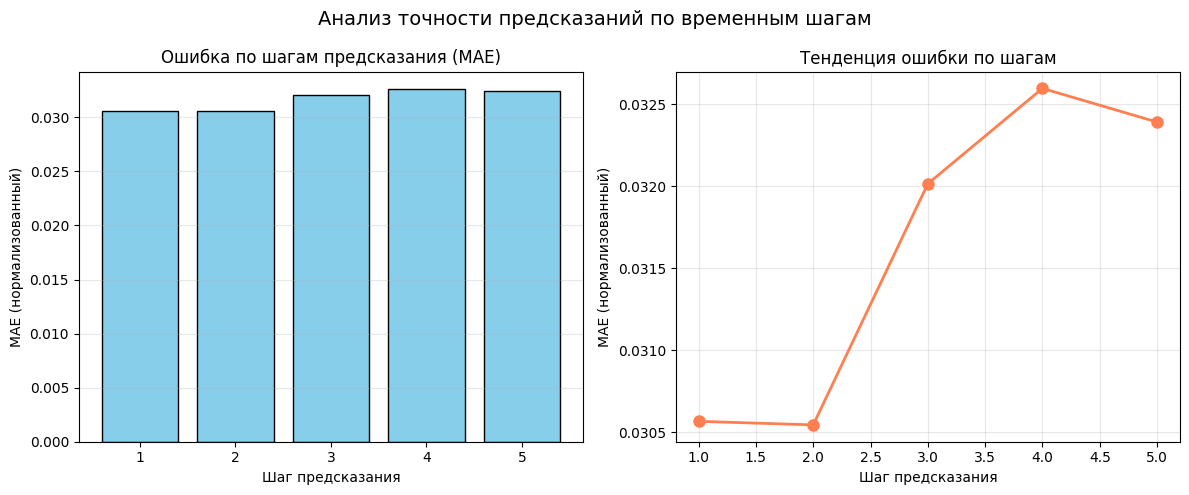

Средняя ошибка по шагам:
  Шаг 1: MAE = 0.030566, MSE = 0.001602
  Шаг 2: MAE = 0.030544, MSE = 0.001662
  Шаг 3: MAE = 0.032016, MSE = 0.001602
  Шаг 4: MAE = 0.032597, MSE = 0.001656
  Шаг 5: MAE = 0.032392, MSE = 0.001686


In [ ]:
def analyze_prediction_steps(predictions, targets, dataset):
    steps = predictions.shape[1]

    step_maes = []
    step_mses = []

    for step in range(steps):
        step_pred = predictions[:, step]
        step_target = targets[:, step]

        step_mae = np.mean(np.abs(step_target - step_pred))
        step_mse = np.mean((step_target - step_pred) ** 2)

        step_maes.append(step_mae)
        step_mses.append(step_mse)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.bar(range(1, steps + 1), step_maes, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Шаг предсказания')
    ax1.set_ylabel('MAE (нормализованный)')
    ax1.set_title('Ошибка по шагам предсказания (MAE)')
    ax1.grid(True, alpha=0.3, axis='y')

    ax2.plot(range(1, steps + 1), step_maes, 'o-', linewidth=2, markersize=8, color='coral')
    ax2.set_xlabel('Шаг предсказания')
    ax2.set_ylabel('MAE (нормализованный)')
    ax2.set_title('Тенденция ошибки по шагам')
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Анализ точности предсказаний по временным шагам', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Средняя ошибка по шагам:")
    for i, (mae, mse) in enumerate(zip(step_maes, step_mses)):
        print(f"  Шаг {i+1}: MAE = {mae:.6f}, MSE = {mse:.6f}")

    return step_maes, step_mses

step_maes, step_mses = analyze_prediction_steps(predictions, targets, dataset)